## Droplet dynamics (Laminar to complex flow transition) - Non-linear test
### Reference: Insights into 2D Navier-Stokes Numerical Simulations, Energy-Conserving Solver Approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0
# 0.05
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 4e-4
# 6e-4
# epsilon**2

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 3.0
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 4

# Forcing
# f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
# f_w_hat = np.fft.fft2(f_w)

# # Time stepping
# T = 1.0
# N_t = 10000
# delta_t = T/N_t
# save_every = 100

T = 10.0
N_t = 25000
delta_t = T/N_t
save_every = 100

# Single droplet parameters

# xc = L_x / 2
# yc = L_y / 2

# xc = 0.47 * L_x
# yc = 0.41 * L_y

# d0 = 0.24 * L_x      

In [3]:
experiment_name = "Experiment_DD_Non_linear_test"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [4]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "nu = 0 (to remove the linear term), a random initial vorticity field is used, f_w = 0",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        # "type": "Kolmogorov-type forcing",
        # "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_Non_linear_test/parameters.json


In [5]:
# Initialise phi
phi_xy = np.ones_like(X)
phi_xy_hat = np.fft.fft2(phi_xy)

In [6]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [7]:
# Assemble \mu using pseudo-spectral implementation

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

initial phi stats: 1.0 1.0 1.0
initial phi hat finite? True


In [8]:
# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [9]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [10]:
# Helper functions for validation


def compute_divergence(u_x, u_y, Kx, Ky):
    """
    Computes divergence of velocity field:
        div u = du_x/dx + du_y/dy
    using spectral derivatives.
    """
    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    div_hat = 1j * Kx * u_x_hat + 1j * Ky * u_y_hat
    div_xy = np.fft.ifft2(div_hat).real

    return div_xy, div_hat


def compute_kinetic_energy(u_x, u_y):
    """
    Kinetic energy per unit area:
        E = 1/2 <u_x^2 + u_y^2>
    """
    return 0.5 * np.mean(u_x**2 + u_y**2)


def compute_enstrophy(omega_xy):
    """
    Enstrophy per unit area:
        Z = 1/2 <omega^2>
    """
    return 0.5 * np.mean(omega_xy**2)


def check_finite_fields(**fields):
    """
    Checks whether all provided arrays contain only finite values.
    """
    results = {}

    for name, arr in fields.items():
        results[name] = np.isfinite(arr).all()

    return results


def analytical_laminar_vorticity(X, Y, f_0, k_f, nu, alpha=0.0):
    """
    Analytical steady vorticity for the forced linear problem:

        0 = nu Delta omega - alpha omega + f_omega

    with

        f_omega = f_0 k_f [cos(k_f x) + cos(k_f y)]

    Then:

        omega_lam = f_0 k_f / (nu k_f^2 + alpha)
                    [cos(k_f x) + cos(k_f y)]
    """
    denominator = nu * k_f**2 + alpha

    return (f_0 * k_f / denominator) * (
        np.cos(k_f * X) + np.cos(k_f * Y)
    )


def compute_error(numerical, analytical):
    """
    Computes common error metrics.
    """
    err = numerical - analytical

    L2_err = np.sqrt(np.mean(err**2))
    Linf_err = np.max(np.abs(err))
    relative_L2_err = L2_err / np.sqrt(np.mean(analytical**2))

    return err, L2_err, Linf_err, relative_L2_err


def taylor_green_exact_vorticity(X, Y, A, a, b, nu, alpha, t):
    """
    Analytical Taylor-Green vorticity solution:

        omega(t,x,y) = A exp(-(nu(a^2+b^2)+alpha)t) sin(ax) sin(by)
    """
    decay_rate = nu * (a**2 + b**2) + alpha
    return A * np.exp(-decay_rate * t) * np.sin(a * X) * np.sin(b * Y)


def taylor_green_exact_enstrophy(E0, decay_rate, t):
    """
    Since omega decays like exp(-decay_rate*t),
    enstrophy decays like exp(-2*decay_rate*t).
    """
    return E0 * np.exp(-2.0 * decay_rate * t)

In [11]:
def G_nonlinear_inviscid(omega_hat, u_x, u_y):
    """
    Nonlinear inviscid RHS for 2D vorticity equation:

        omega_t = - u · grad(omega)

    Returns Fourier-space RHS.
    """

    rhs_hat = -advection_omega(omega_hat, u_x, u_y)
    rhs_hat = dealias(rhs_hat)

    return rhs_hat

In [12]:
def random_vorticity_field(Kx, Ky, seed=1, decay_rate=0.15, target_enstrophy=1.0):
    """
    Generates a smooth random mean-zero vorticity field in Fourier space.

    The spectrum has random phases and exponential decay:
        omega_hat(k) ~ exp(-decay_rate * |k|) * exp(i phase)

    Then the physical-space field is normalized to a chosen enstrophy.
    """

    rng = np.random.default_rng(seed)

    K_abs = np.sqrt(Kx**2 + Ky**2)

    # Random phases
    phases = rng.uniform(-np.pi, np.pi, size=Kx.shape)

    # Smooth spectral amplitude
    amplitude = np.exp(-decay_rate * K_abs)

    # Remove zero mode
    amplitude[0, 0] = 0.0

    # Complex Fourier coefficients
    omega_hat_random = amplitude * np.exp(1j * phases)

    # Enforce real-valued physical field by going to physical space and back
    omega_xy = np.fft.ifft2(omega_hat_random).real

    # Remove mean
    omega_xy -= np.mean(omega_xy)

    # Normalize enstrophy
    current_enstrophy = compute_enstrophy(omega_xy)

    if current_enstrophy <= 1e-14:
        raise ValueError("Generated vorticity has near-zero enstrophy. Change seed/decay_rate.")

    omega_xy *= np.sqrt(target_enstrophy / current_enstrophy)

    omega_hat = np.fft.fft2(omega_xy)

    return omega_xy, omega_hat

In [13]:
# Start from initial vorticity
omega_xy_0, omega_hat_0 = random_vorticity_field(
    Kx=Kx,
    Ky=Ky,
    seed=5,
    decay_rate=0.20,
    target_enstrophy=1.0
)

q_01_n = omega_hat_0.copy()


In [14]:
# ============================================================
# Nonlinear inviscid test settings
# ============================================================

lamda_01_nonlinear = np.zeros_like(K2, dtype=complex)

E_01 = np.exp(lamda_01_nonlinear * delta_t)

# Since lambda = 0 everywhere:
phi1 = delta_t * np.ones_like(K2, dtype=complex)
phi_1 = 0.5 * delta_t * np.ones_like(K2, dtype=complex)


# ============================================================
# Histories
# ============================================================

omega_history = []
time_history = []
kinetic_energy_history = []
enstrophy_history = []
relative_enstrophy_drift_history = []
relative_kinetic_energy_drift_history = []
max_divergence_history = []
finite_check_history = []
max_omega_history = []
max_rhs_history = []

# Initial diagnostics
u_x_0, u_y_0 = recover_velocity(q_01_n)

E0_kinetic = compute_kinetic_energy(u_x_0, u_y_0)
Z0_enstrophy = compute_enstrophy(omega_xy_0)

print("Initial kinetic energy =", E0_kinetic)
print("Initial enstrophy      =", Z0_enstrophy)

# ============================================================
# Time stepping: nonlinear inviscid vorticity equation
# ============================================================

for n in range(N_t + 1):

    t = n * delta_t

    # Current physical vorticity and velocity
    omega_xy_n = np.fft.ifft2(q_01_n).real
    u_x_n, u_y_n = recover_velocity(q_01_n)

    # Save diagnostics
    if n % save_every == 0:

        div_xy, div_hat = compute_divergence(u_x_n, u_y_n, Kx, Ky)
        max_divergence = np.max(np.abs(div_xy))

        finite_checks = check_finite_fields(
            omega_hat=q_01_n,
            omega_xy=omega_xy_n,
            u_x=u_x_n,
            u_y=u_y_n,
            div_xy=div_xy
        )

        kinetic_energy = compute_kinetic_energy(u_x_n, u_y_n)
        enstrophy = compute_enstrophy(omega_xy_n)

        relative_enstrophy_drift = abs(enstrophy - Z0_enstrophy) / Z0_enstrophy
        relative_kinetic_energy_drift = abs(kinetic_energy - E0_kinetic) / E0_kinetic

        # Nonlinear RHS size
        G_n = G_nonlinear_inviscid(q_01_n, u_x_n, u_y_n)
        max_rhs = np.max(np.abs(G_n))

        omega_history.append(omega_xy_n.copy())
        time_history.append(t)
        kinetic_energy_history.append(kinetic_energy)
        enstrophy_history.append(enstrophy)
        relative_enstrophy_drift_history.append(relative_enstrophy_drift)
        relative_kinetic_energy_drift_history.append(relative_kinetic_energy_drift)
        max_divergence_history.append(max_divergence)
        finite_check_history.append(finite_checks)
        max_omega_history.append(np.max(np.abs(omega_xy_n)))
        max_rhs_history.append(max_rhs)

        print(
            f"step {n}/{N_t}, "
            f"t={t:.4f}, "
            f"K={kinetic_energy:.6e}, "
            f"Z={enstrophy:.6e}, "
            f"rel_Z_drift={relative_enstrophy_drift:.4e}, "
            f"rel_K_drift={relative_kinetic_energy_drift:.4e}, "
            f"max|omega|={np.max(np.abs(omega_xy_n)):.4e}, "
            f"max|div u|={max_divergence:.4e}"
        )

        if not all(finite_checks.values()):
            print("Non-finite field detected.")
            print(finite_checks)
            break

    # Do not step beyond final time
    if n == N_t:
        break

    # --------------------------------------------------------
    # ETD2 / explicit midpoint-like nonlinear update
    # Since lambda = 0, this becomes:
    #   a = q_n + dt G_n
    #   q_next = a + 0.5 dt (G_a - G_n)
    #          = q_n + 0.5 dt (G_n + G_a)
    # --------------------------------------------------------

    # RHS at current state
    u_x_n, u_y_n = recover_velocity(q_01_n)
    G_n = G_nonlinear_inviscid(q_01_n, u_x_n, u_y_n)

    # Predictor
    a_01_n = q_01_n * E_01 + G_n * phi1

    # RHS at predictor state
    u_x_a, u_y_a = recover_velocity(a_01_n)
    G_a = G_nonlinear_inviscid(a_01_n, u_x_a, u_y_a)

    # Corrector
    q_01_next = a_01_n + (G_a - G_n) * phi_1

    # Dealias final vorticity
    q_01_next = dealias(q_01_next)

    # Optional: enforce zero mean vorticity
    q_01_next[0, 0] = 0.0

    # Update
    q_01_n = q_01_next

Initial kinetic energy = 0.11533736736152009
Initial enstrophy      = 0.9999999999999998
step 0/25000, t=0.0000, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=0.0000e+00, rel_K_drift=0.0000e+00, max|omega|=5.2382e+00, max|div u|=3.8002e-14
step 100/25000, t=0.0400, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=1.3287e-11, rel_K_drift=5.7026e-12, max|omega|=5.2324e+00, max|div u|=3.5355e-14
step 200/25000, t=0.0800, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=1.1887e-10, rel_K_drift=1.1594e-11, max|omega|=5.2364e+00, max|div u|=4.1936e-14
step 300/25000, t=0.1200, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=2.2581e-10, rel_K_drift=1.7499e-11, max|omega|=5.2305e+00, max|div u|=3.7255e-14
step 400/25000, t=0.1600, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=3.3455e-10, rel_K_drift=2.3418e-11, max|omega|=5.2398e+00, max|div u|=4.0980e-14
step 500/25000, t=0.2000, K=1.153374e-01, Z=1.000000e+00, rel_Z_drift=4.4556e-10, rel_K_drift=2.9351e-11, max|omega|=5.2390e+00, max|div u|=3.7446e-14
step 60

### Validation:

In [15]:
# Convert histories to arrays
time_history = np.array(time_history)
kinetic_energy_history = np.array(kinetic_energy_history)
enstrophy_history = np.array(enstrophy_history)
relative_enstrophy_drift_history = np.array(relative_enstrophy_drift_history)
relative_kinetic_energy_drift_history = np.array(relative_kinetic_energy_drift_history)
max_divergence_history = np.array(max_divergence_history)
max_omega_history = np.array(max_omega_history)
max_rhs_history = np.array(max_rhs_history)

# Final fields
omega_num = np.fft.ifft2(q_01_n).real
u_x, u_y = recover_velocity(q_01_n)

div_xy, div_hat = compute_divergence(u_x, u_y, Kx, Ky)
max_divergence = np.max(np.abs(div_xy))

finite_checks = check_finite_fields(
    omega_hat=q_01_n,
    omega_xy=omega_num,
    u_x=u_x,
    u_y=u_y,
    div_xy=div_xy
)

print("========== NONLINEAR INVISCID VORTICITY TEST ==========")

print("\n1. Incompressibility")
print("max |div u| =", max_divergence)

print("\n2. Finite field checks")
for name, status in finite_checks.items():
    print(f"{name}: {status}")

print("\n3. Kinetic energy conservation")
print("Initial kinetic energy =", kinetic_energy_history[0])
print("Final kinetic energy   =", kinetic_energy_history[-1])
print("Relative kinetic energy drift =", relative_kinetic_energy_drift_history[-1])

print("\n4. Enstrophy conservation")
print("Initial enstrophy =", enstrophy_history[0])
print("Final enstrophy   =", enstrophy_history[-1])
print("Relative enstrophy drift =", relative_enstrophy_drift_history[-1])

print("\n5. Vorticity magnitude")
print("Initial max |omega| =", max_omega_history[0])
print("Final max |omega|   =", max_omega_history[-1])

print("\n=======================================================")

========== NONLINEAR INVISCID VORTICITY TEST ==========

1. Incompressibility
max |div u| = 3.9106323723035495e-14

2. Finite field checks
omega_hat: True
omega_xy: True
u_x: True
u_y: True
div_xy: True

3. Kinetic energy conservation
Initial kinetic energy = 0.11533736736152009
Final kinetic energy   = 0.11533736853998577
Relative kinetic energy drift = 1.0217553192912999e-08

4. Enstrophy conservation
Initial enstrophy = 0.9999999999999998
Final enstrophy   = 1.0000035654649555
Relative enstrophy drift = 3.5654649557237414e-06

5. Vorticity magnitude
Initial max |omega| = 5.238223753067725
Final max |omega|   = 6.640104786110796



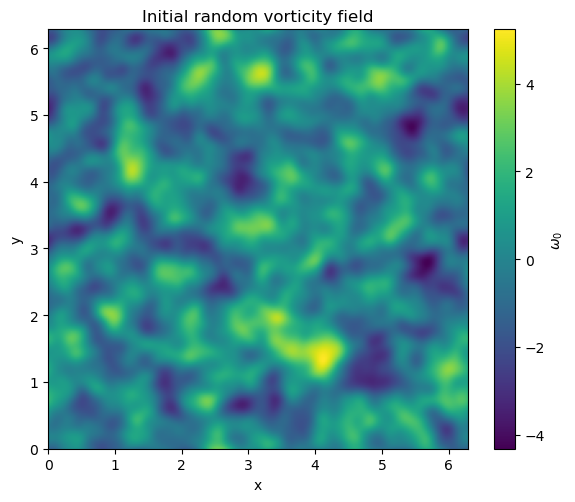

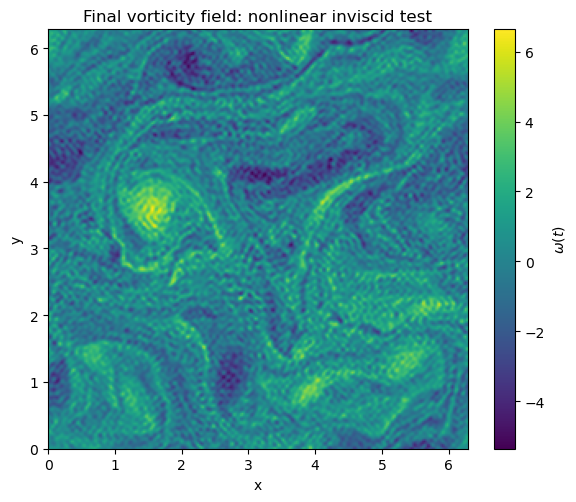

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(
    omega_xy_0,
    origin="lower",
    extent=[0, L_x, 0, L_y]
)
plt.colorbar(label=r"$\omega_0$")
plt.title("Initial random vorticity field")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    omega_num,
    origin="lower",
    extent=[0, L_x, 0, L_y]
)
plt.colorbar(label=r"$\omega(t)$")
plt.title("Final vorticity field: nonlinear inviscid test")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

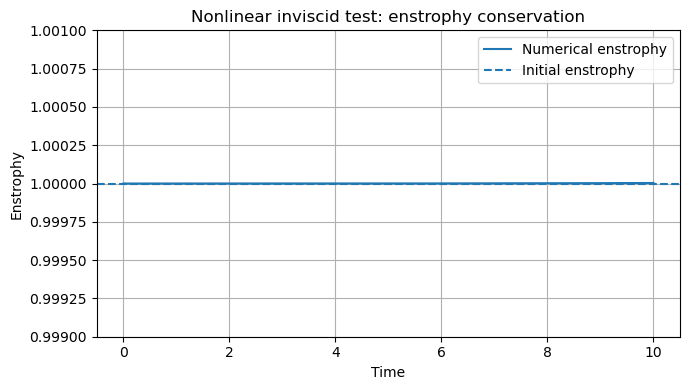

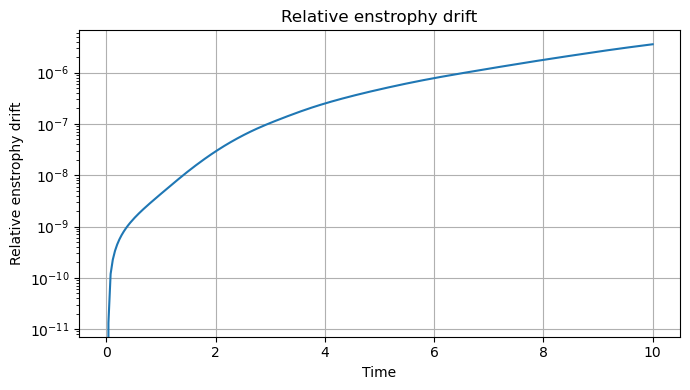

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, enstrophy_history, label="Numerical enstrophy")
plt.axhline(enstrophy_history[0], linestyle="--", label="Initial enstrophy")
plt.ylim(0.999, 1.001)
plt.xlabel("Time")
plt.ylabel("Enstrophy")
plt.title("Nonlinear inviscid test: enstrophy conservation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(time_history, relative_enstrophy_drift_history)
plt.xlabel("Time")
plt.ylabel("Relative enstrophy drift")
plt.title("Relative enstrophy drift")
plt.grid(True)
plt.tight_layout()
plt.show()

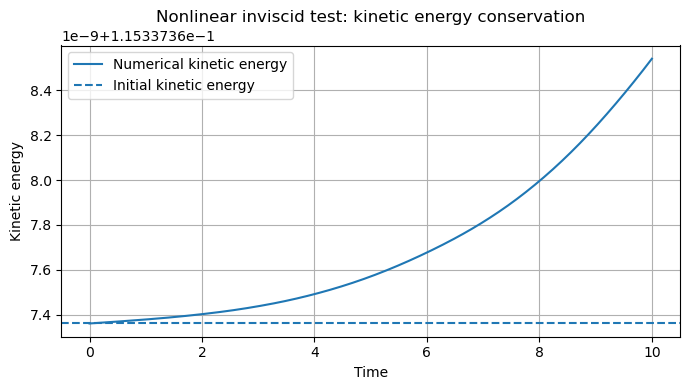

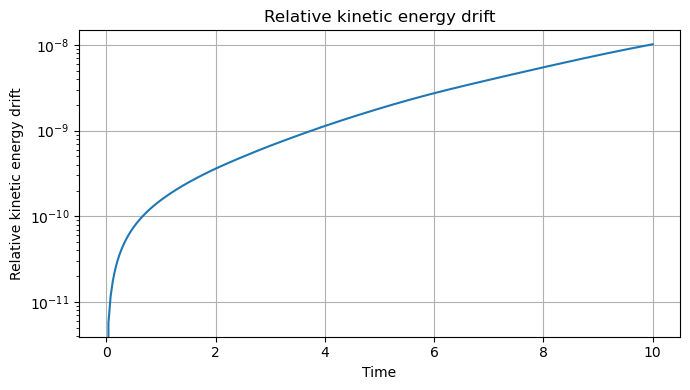

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, kinetic_energy_history, label="Numerical kinetic energy")
plt.axhline(kinetic_energy_history[0], linestyle="--", label="Initial kinetic energy")
plt.xlabel("Time")
plt.ylabel("Kinetic energy")
plt.title("Nonlinear inviscid test: kinetic energy conservation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(time_history, relative_kinetic_energy_drift_history)
plt.xlabel("Time")
plt.ylabel("Relative kinetic energy drift")
plt.title("Relative kinetic energy drift")
plt.grid(True)
plt.tight_layout()
plt.show()

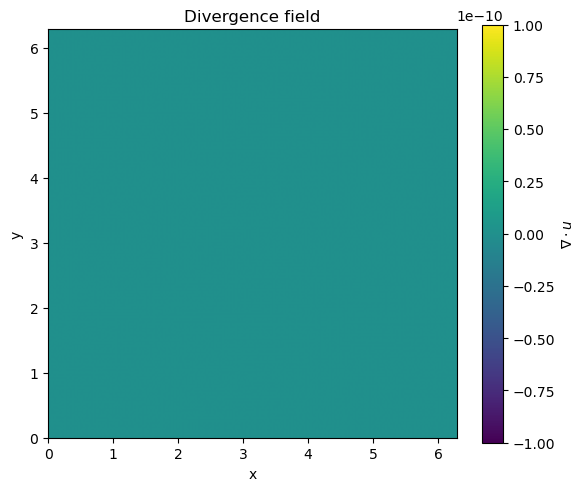

In [19]:
plt.figure(figsize=(6, 5))
plt.imshow(
    div_xy,
    origin="lower",
    extent=[0, L_x, 0, L_y],
    vmin=-1e-10,
    vmax=1e-10
)
plt.colorbar(label=r"$\nabla\cdot u$")
plt.title("Divergence field")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

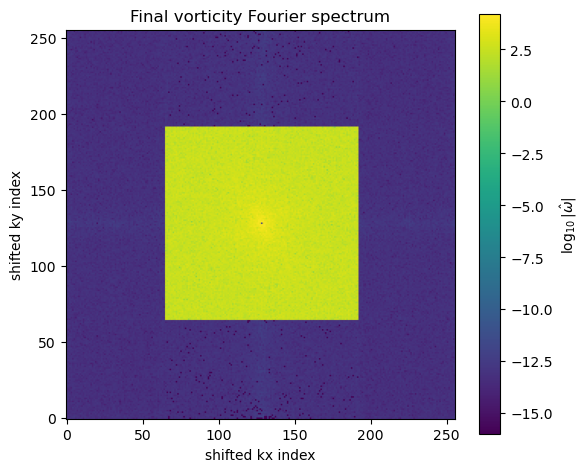

In [20]:
omega_hat_final = np.fft.fft2(omega_num)
omega_amp = np.abs(np.fft.fftshift(omega_hat_final))

plt.figure(figsize=(6, 5))
plt.imshow(
    np.log10(omega_amp + 1e-16),
    origin="lower"
)
plt.colorbar(label=r"$\log_{10}|\hat{\omega}|$")
plt.title("Final vorticity Fourier spectrum")
plt.xlabel("shifted kx index")
plt.ylabel("shifted ky index")
plt.tight_layout()
plt.show()

In [21]:
omega_difference = omega_history[-1] - omega_history[0]

print("L2 change in omega =", np.sqrt(np.mean(omega_difference**2)))
print("max change in omega =", np.max(np.abs(omega_difference)))

L2 change in omega = 1.9963987485048766
max change in omega = 8.007361792519905
